In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("killa92/crop-disease-image-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'crop-disease-image-classification-dataset' dataset.
Path to dataset files: /kaggle/input/crop-disease-image-classification-dataset


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os
print(os.listdir(path))

['crop_disease_dataset']


In [ ]:
csv_path = os.path.join(path, "crop_disease_dataset")
print(os.listdir(csv_path))

['images', 'meta_deta.csv', 'class_names.json']


CSV, images yüklədin.
CSV və images fayllarını birləşdirmək üçün imagesda olan idləri işlədərək CSV ilə birləşdirdiyini CSVdə olub imagesda olmayan idləri ataq.

birləşdirdiyimiz dfdə labellər var biz onların sayına baxırıq ki hansından nə qədər var. train, test splitdə necə böləcəyik. sonra json faylı daxilində bizim 5 labellərin adları var onları əlavə edirik df datada null dəyər yoxdursa hər şey yolundadırsa keçirik növbəti mərhələyə

In [ ]:
df = pd.read_csv(os.path.join(csv_path, "meta_deta.csv"), on_bad_lines="skip")
df.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [ ]:
df.tail()

,image_id,label
21392,999068805.jpg,3
21393,999329392.jpg,3
21394,999474432.jpg,1
21395,999616605.jpg,4
21396,999998473.jpg,4


In [ ]:
df['label'].value_counts()

,count
label,
3,13158
4,2577
2,2386
1,2189
0,1087


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21397 entries, 0 to 21396
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image_id  21397 non-null  object
 1   label     21397 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 334.5+ KB


In [ ]:
import os



image_dir = os.path.join(path, "crop_disease_dataset", "images")



images = os.listdir(image_dir)

print(images[:10])
print(len(images))

['478554372.jpg', '2763304605.jpg', '2826122413.jpg', '231268038.jpg', '4201965605.jpg', '3224710052.jpg', '2530575673.jpg', '720275537.jpg', '3459977804.jpg', '2174460518.jpg']
17938


In [ ]:
df["exists"] = df["image_id"].isin(images)

df = df[df["exists"] == True].copy()
df.drop(columns=["exists"], inplace=True)

In [ ]:
df.shape

(17938, 2)

In [ ]:
df.head()

,image_id,label
3282,157078263.jpg,3
3297,1574893536.jpg,3
3298,1575013487.jpg,3
3309,1576606254.jpg,0
3323,1579761476.jpg,1


In [ ]:
import json

json_path = os.path.join(csv_path, "class_names.json")

with open(json_path, "r") as f:
    label_map = json.load(f)

print(label_map)

{'0': 'Cassava Bacterial Blight (CBB)', '1': 'Cassava Brown Streak Disease (CBSD)', '2': 'Cassava Green Mottle (CGM)', '3': 'Cassava Mosaic Disease (CMD)', '4': 'Healthy'}


In [ ]:
df["label_name"] = df["label"].astype(str).map(label_map)

df.head()

,image_id,label,label_name
3282,157078263.jpg,3,Cassava Mosaic Disease (CMD)
3297,1574893536.jpg,3,Cassava Mosaic Disease (CMD)
3298,1575013487.jpg,3,Cassava Mosaic Disease (CMD)
3309,1576606254.jpg,0,Cassava Bacterial Blight (CBB)
3323,1579761476.jpg,1,Cassava Brown Streak Disease (CBSD)


In [ ]:
df.tail()

,image_id,label,label_name
21392,999068805.jpg,3,Cassava Mosaic Disease (CMD)
21393,999329392.jpg,3,Cassava Mosaic Disease (CMD)
21394,999474432.jpg,1,Cassava Brown Streak Disease (CBSD)
21395,999616605.jpg,4,Healthy
21396,999998473.jpg,4,Healthy


In [ ]:
df["image_path"] = df["image_id"].apply(
    lambda x: os.path.join(image_dir, x)
)

In [ ]:
df.isnull().sum()

,0
image_id,0
label,0
label_name,0
image_path,0


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

In [ ]:
train_transform = A.Compose([

    A.Resize(224, 224),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.2),

    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit=0.1,
        rotate_limit=30,
        p=0.5
    ),

    A.Normalize(),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
val_transform = A.Compose([
    A.Normalize(),
    ToTensorV2()
])

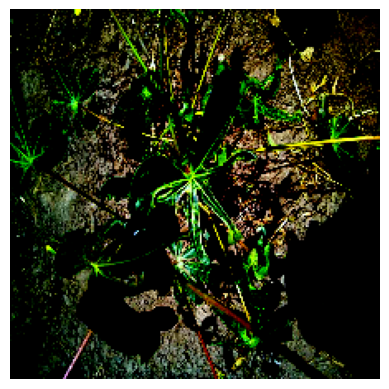

In [ ]:
import matplotlib.pyplot as plt
import cv2

img_path = df["image_path"].iloc[0]

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

augmented = train_transform(image=image)["image"]

plt.imshow(augmented.permute(1,2,0))
plt.axis("off")
plt.show()

In [ ]:
df.head()

,image_id,label,label_name,image_path
3282,157078263.jpg,3,Cassava Mosaic Disease (CMD),/kaggle/input/crop-disease-image-classificatio...
3297,1574893536.jpg,3,Cassava Mosaic Disease (CMD),/kaggle/input/crop-disease-image-classificatio...
3298,1575013487.jpg,3,Cassava Mosaic Disease (CMD),/kaggle/input/crop-disease-image-classificatio...
3309,1576606254.jpg,0,Cassava Bacterial Blight (CBB),/kaggle/input/crop-disease-image-classificatio...
3323,1579761476.jpg,1,Cassava Brown Streak Disease (CBSD),/kaggle/input/crop-disease-image-classificatio...


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2

In [ ]:
val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(),
    ToTensorV2()
])

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print(len(train_df), len(val_df), len(test_df))

12556 2691 2691


In [ ]:
class CropDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = cv2.imread(row["image_path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        label = row["label"]

        if self.transform:
            image = self.transform(image=image)["image"]

        return image, torch.tensor(label, dtype=torch.long)

In [ ]:
train_dataset = CropDataset(train_df, transform=train_transform)
val_dataset = CropDataset(val_df, transform=val_transform)

In [ ]:
from efficientnet_pytorch import EfficientNet
import torch.nn as nn

In [ ]:
model = EfficientNet.from_pretrained('efficientnet-b3')

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b3-5fb5a3c3.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b3-5fb5a3c3.pth


100%|██████████| 47.1M/47.1M [00:00<00:00, 168MB/s]


Loaded pretrained weights for efficientnet-b3


In [ ]:
num_classes = df["label"].nunique()
print(num_classes)

5


In [ ]:
in_features = model._fc.in_features

model._fc = nn.Linear(in_features, num_classes)

In [ ]:
model

EfficientNet(
  (_conv_stem): Conv2dStaticSamePadding(
    3, 40, kernel_size=(3, 3), stride=(2, 2), bias=False
    (static_padding): ZeroPad2d((0, 1, 0, 1))
  )
  (_bn0): BatchNorm2d(40, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
  (_blocks): ModuleList(
    (0): MBConvBlock(
      (_depthwise_conv): Conv2dStaticSamePadding(
        40, 40, kernel_size=(3, 3), stride=[1, 1], groups=40, bias=False
        (static_padding): ZeroPad2d((1, 1, 1, 1))
      )
      (_bn1): BatchNorm2d(40, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
      (_se_reduce): Conv2dStaticSamePadding(
        40, 10, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_se_expand): Conv2dStaticSamePadding(
        10, 40, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_project_conv): Conv2dStaticSamePadding(
        40, 24, kernel_size=(1, 1), stride=(1, 1), bias=False
  

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
print(len(train_loader))

393


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
device = torch.device("cuda")

model = model.to(device)

print(device)

cuda


In [92]:
epochs = 5

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {train_loss/len(train_loader)}")

Epoch 1, Loss: 0.34012008028024326
Epoch 2, Loss: 0.3005958331260669
Epoch 3, Loss: 0.2836369234149086
Epoch 4, Loss: 0.2518548810091486
Epoch 5, Loss: 0.21936976283542226


In [93]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Validation Accuracy:", correct/total)

Validation Accuracy: 0.8409513192121888


In [94]:
from sklearn.metrics import classification_report
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.61      0.54      0.57       138
           1       0.70      0.77      0.73       274
           2       0.73      0.65      0.69       299
           3       0.95      0.94      0.94      1655
           4       0.63      0.70      0.67       325

    accuracy                           0.84      2691
   macro avg       0.72      0.72      0.72      2691
weighted avg       0.84      0.84      0.84      2691

